# Exploración computacional de la regresión logística

Este cuaderno no se definenfunciones, todas son importadas de src

In [1]:
import sys
sys.path.append("..")  # para poder importar el paquete src desde notebooks

import numpy as np
import matplotlib.pyplot as plt

from src.modelo import sigmoid, p_theta, riesgo_empirico
from src.optimizacion import ajustar_modelo
from src.simulacion import generar_datos

## Ejercicio 1 — Superficie del riesgo logístico

Datos del enunciado y malla de valores de $\theta=(\theta_0,\theta_1)$.

considerando los siguientes datos

In [ ]:
x = np.array([-2, -1.5, -1, -0.5, 0, 0.5, 1, 1.5, 2]) #datos de entrada 
y = np.array([0, 0, 0, 1, 0, 1, 1, 1, 1]) #datos de salida

**(a)** Evaliación del riesgo empirico

In [ ]:
theta0_vals = np.linspace(-4, 4, 100) #genera 100 valores de theta0 entre -4 y 4
theta1_vals = np.linspace(-1, 6, 100) #genera 100 valores de theta1 entre -1 y 6
T0, T1 = np.meshgrid(theta0_vals, theta1_vals) #la función meshgrid genera una malla de valores de theta0 y theta1 para evaluar el riesgo empírico en cada punto de la malla con las posibles combinaciones de theta0 y theta1. 
#T0 y T1 son matrices que contienen los valores de theta0 y theta1 respectivamente para cada punto de la malla.

R = np.zeros_like(T0) #matrz de ceros con la misma forma que T0 para almacenar los valores del riesgo empírico calculados en cada punto de la malla.
for i in range(T0.shape[0]):
    for j in range(T0.shape[1]):
        R[i, j] = riesgo_empirico((T0[i, j], T1[i, j]), x, y) # calcula el riesgo empírico para cada combinación de theta0 y theta1 en la malla y lo almacena en la matriz R.

 **(b)**  superficie 3D del riesgo y un gráfico de curvas de nivel

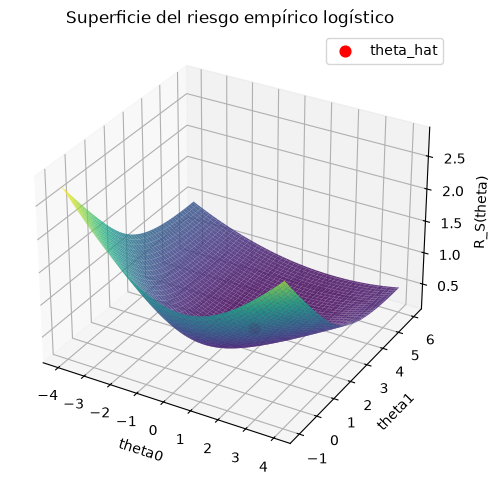

In [14]:
fig = plt.figure(figsize=(7, 5))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(T0, T1, R, cmap="viridis", alpha=0.85)
ax.scatter([theta_hat[0]], [theta_hat[1]], [R_hat], color="red", s=60, label="theta_hat")
ax.set_xlabel("theta0")
ax.set_ylabel("theta1")
ax.set_zlabel("R_S(theta)")
ax.set_title("Superficie del riesgo empírico logístico")
ax.legend()
plt.tight_layout()
plt.savefig("../resultados/ej1_superficie.png", dpi=150)
plt.show()

La superficie del riesgo empírico muestra un único valle, el riesgo desciende de forma continua hacia un mínimo global. Ese mínimo se alcanza en $\hat\theta\approx(0.65,\,2.58)$, marcado en rojo en la superficie 3D , este es el punto que se identificó visualmente al observar la gráfica, con un $\theta_0$ ligeramente positivo y un $\theta_1$ cercano a la parte alta del rango explorado.
En el extremo opuesto, el riesgo más alto de toda la malla se ubica en la esquina $(\theta_0,\theta_1)=(-4,-1)$.

**(C)** Use scipy.optimize.minimize desde (0,0) para obtener θ. Reporte θ y RS(θ).

In [ ]:
theta_hat, resultado = ajustar_modelo(x, y, theta_init=np.array([0.0, 0.0]))# ajusta el modelo logístico a los datos (x,y) usando como punto de inicio theta_init = (0,0). Devuelve el parámetro optimizado theta_hat y un objeto resultado que contiene información sobre la optimización.
R_hat = riesgo_empirico(theta_hat, x, y) # calcula el riesgo empírico para el parámetro optimizado
print("theta_hat =", theta_hat)
print("R_S(theta_hat) =", R_hat)

theta_hat = [0.65000891 2.58448731]
R_S(theta_hat) = 0.27845423892329313


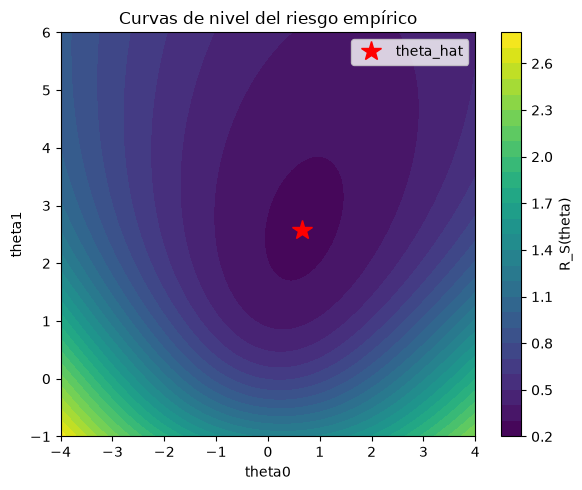

In [5]:
# (b) Curvas de nivel, con el minimizador marcado (d)
fig, ax = plt.subplots(figsize=(6, 5))
cf = ax.contourf(T0, T1, R, levels=30, cmap="viridis")
ax.plot(theta_hat[0], theta_hat[1], "r*", markersize=15, label="theta_hat")
ax.set_xlabel("theta0")
ax.set_ylabel("theta1")
ax.set_title("Curvas de nivel del riesgo empírico")
fig.colorbar(cf, ax=ax, label="R_S(theta)")
ax.legend()
plt.tight_layout()
plt.savefig("../resultados/ej1_curvas_nivel.png", dpi=150)
plt.show()  

Este mismo mínimo se puede identificar visualmente en el gráfico de curvas de nivel, la zona central, de color más oscuro, converge hacia el punto marcado con la estrella roja  es la misma conclusión que arroja la verificación numérica del ítem (d), pero  sin necesidad de calcular nada.

**(d)** Verificación numérica de que theta_hat es un mínimo local (en las dos direcciones de los ejes):

In [6]:
R_mas_theta0 = riesgo_empirico(theta_hat + np.array([0.1, 0.0]), x, y)
R_mas_theta1 = riesgo_empirico(theta_hat + np.array([0.0, 0.1]), x, y)

print("R_S(theta_hat)              =", R_hat)
print("R_S(theta_hat + (0.1, 0))   =", R_mas_theta0, " -> cumple:", R_hat < R_mas_theta0)
print("R_S(theta_hat + (0, 0.1))   =", R_mas_theta1, " -> cumple:", R_hat < R_mas_theta1)

R_S(theta_hat)              = 0.27845423892329313
R_S(theta_hat + (0.1, 0))   = 0.2788813439212031  -> cumple: True
R_S(theta_hat + (0, 0.1))   = 0.2786645912275856  -> cumple: True


Para confirmar que $\hat\theta$ es realmente un mínimo, se evalua el riesgo en dos puntos vecinos: $\hat\theta+(0.1,0)$ y $\hat\theta+(0,0.1)$. En ambos casos el riesgo resultó mayor que en $\hat\theta$, lo que confirma que moverse en cualquiera de las dos direcciones empeora el ajuste, justo lo que se espera si $\hat\theta$ está en el fondo del valle de la superficie. Esta comprobación numérica coincide con lo que se observa visualmente en las curvas de nivel, alrededor del punto marcado

## Ejercicio 2 — Datos separables y no separables

In [23]:
y_A = np.array([0, 0, 0, 0, 1, 1, 1, 1, 1])   # separable
y_B = np.array([0, 0, 0, 1, 0, 1, 1, 1, 1])   # no separable

theta_hat_A, _ = ajustar_modelo(x, y_A)
theta_hat_B, _ = ajustar_modelo(x, y_B)

R_A = riesgo_empirico(theta_hat_A, x, y_A)
R_B = riesgo_empirico(theta_hat_B, x, y_B)

In [24]:
# (b) Tabla resumen
print(f"{'conjunto':10s} {'||theta_hat||^2':>18s} {'R_S(theta_hat)':>16s}")
print(f"{'A':10s} {np.sum(theta_hat_A**2):18.4f} {R_A:16.6f}")
print(f"{'B':10s} {np.sum(theta_hat_B**2):18.4f} {R_B:16.6f}")

conjunto      ||theta_hat||^2   R_S(theta_hat)
A                   1853.1183         0.000010
B                      7.1021         0.278454


El conjunto A separable tiene $\|\hat\theta\|^2\approx1853$, muchísimo más grande que el de B ($\|\hat\theta\|^2\approx7.1$). Su riesgo también es distinto: $R_S(A)\approx0.00001$ (casi cero) contra $R_S(B)\approx0.278$.

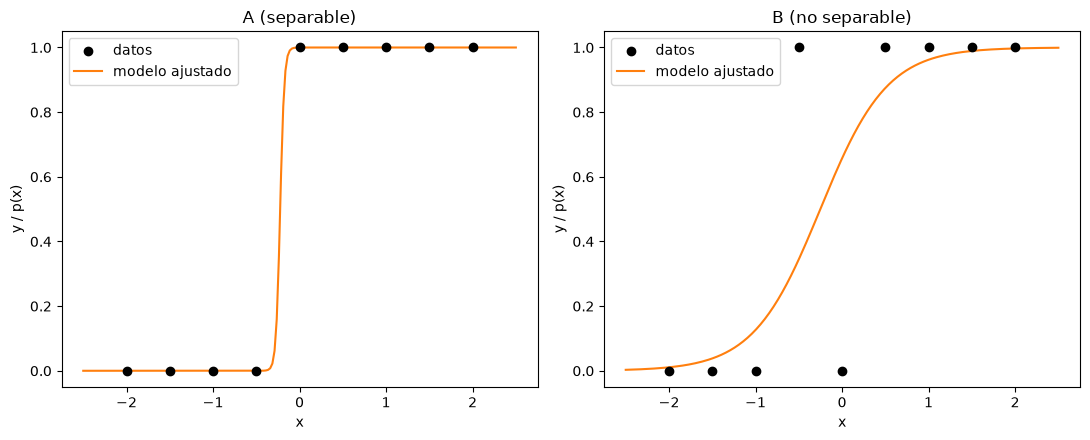

In [25]:
# (c) Datos y curva ajustada, un conjunto en cada panel
x_curva = np.linspace(-2.5, 2.5, 200)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, (nombre, yy, th) in zip(
    axes, [("A (separable)", y_A, theta_hat_A), ("B (no separable)", y_B, theta_hat_B)]
):
    ax.scatter(x, yy, color="black", zorder=3, label="datos")
    ax.plot(x_curva, p_theta(th, x_curva), color="C1", label="modelo ajustado")
    ax.set_title(nombre)
    ax.set_xlabel("x")
    ax.set_ylabel("y / p(x)")
    ax.legend()
plt.tight_layout()
plt.savefig("../resultados/ej2_ajustes.png", dpi=150)
plt.show()

En el conjunto A, la curva ajustada se ve que pasa por los puntos y sube rapidamente de 0 a 1 es consecuencia de que $\|\hat\theta\|^2$ sea tan grande. En el conjunto B, la curva es una transición mucho más suave y gradual entre 0 y 1, reflejando que el modelo no puede ajustar perfectamente esos datos.

**(d)** Comparación de `maxiter=10` vs `maxiter=100` sobre el conjunto separable (A):

In [26]:
theta_10, _ = ajustar_modelo(x, y_A, maxiter=10)
theta_100, _ = ajustar_modelo(x, y_A, maxiter=100)

norma_10, R_10 = np.sum(theta_10**2), riesgo_empirico(theta_10, x, y_A)
norma_100, R_100 = np.sum(theta_100**2), riesgo_empirico(theta_100, x, y_A)

print(f"maxiter=10  -> ||theta||^2 = {norma_10:.4f}, R_S = {R_10:.6f}")
print(f"maxiter=100 -> ||theta||^2 = {norma_100:.4f}, R_S = {R_100:.6f}")
print()
print("La norma aumenta:", norma_100 > norma_10)
print("El riesgo disminuye:", R_100 < R_10)
print("=> Afirmación compatible: II (la norma aumenta mientras el riesgo disminuye hacia cero)")

maxiter=10  -> ||theta||^2 = 256.8653, R_S = 0.005126
maxiter=100 -> ||theta||^2 = 1853.1183, R_S = 0.000010

La norma aumenta: True
El riesgo disminuye: True
=> Afirmación compatible: II (la norma aumenta mientras el riesgo disminuye hacia cero)


Con maxiter=10, el optimizador se detiene temprano: $\|\hat\theta\|^2\approx257$ y $R_S\approx0.0051$. Con maxiter=100, se le permite seguir iterando mucho más: $\|\hat\theta\|^2\approx1853$ y $R_S\approx0.00001$ .

El patrón se da por entre más iteraciones se permiten, más crece la norma de $\theta$ y más baja el riesgo — nunca se estabilizan juntos. Esto confirma que, para datos separables, no existe un $\theta$ finito óptimo: el mínimo verdadero está "en el infinito", y el optimizador simplemente se acerca cada vez más mientras se le deje iterar. Por eso la afirmación compatible con estos resultados es la II: la norma aumenta mientras el riesgo disminuye hacia cero.

## Ejercicio 3 Recuperación de parámetros

Modelo generador: $P(Y=1\mid X=x)=\sigma(-1+2x)$, es decir $\theta^\star=(-1, 2)$.

In [27]:
theta_star = np.array([-1.0, 2.0])
rng = np.random.default_rng(2026)  # un único rng, se reutiliza para los 3 tamaños

resultados_ej3 = []
for n in [50, 200, 1000]:
    x_n, y_n = generar_datos(n, theta_star, rng)
    theta_hat_n, _ = ajustar_modelo(x_n, y_n)
    e_n = np.linalg.norm(theta_hat_n - theta_star)
    resultados_ej3.append((n, theta_hat_n[0], theta_hat_n[1], e_n))

In [28]:
print(f"{'n':>6s} {'theta0_hat':>12s} {'theta1_hat':>12s} {'e_n':>10s}")
for n, t0, t1, e in resultados_ej3:
    print(f"{n:6d} {t0:12.4f} {t1:12.4f} {e:10.4f}")

n_mejor = min(resultados_ej3, key=lambda fila: fila[3])[0]
e_50 = [fila[3] for fila in resultados_ej3 if fila[0] == 50][0]
e_1000 = [fila[3] for fila in resultados_ej3 if fila[0] == 1000][0]

print()
print("n con menor error:", n_mejor)
print("¿e_1000 < e_50?", e_1000 < e_50)

     n   theta0_hat   theta1_hat        e_n
    50      -1.6138       2.6844     0.9193
   200      -0.8230       2.0382     0.1811
  1000      -1.0660       1.8500     0.1639

n con menor error: 1000
¿e_1000 < e_50? True


A medida que aumenta el tamaño de muestra $n$, el error $e_n=\|\hat\theta_n-\theta^\star\|$ disminuye: pasa de $e_{50}\approx0.92$ a $e_{200}\approx0.18$ y $e_{1000}\approx0.16$. El salto más grande ocurre entre $n=50$ y $n=200$ — con muy pocos datos, el modelo estima parámetros muy alejados del verdadero $\theta^\star=(-1,2)$ (con $n=50$ se obtiene $\hat\theta\approx(-1.61,\,2.68)$), pero con $n=200$ ya se acerca considerablemente ($\hat\theta\approx(-0.82,\,2.04)$).
Entre $n=200$ y $n=1000$ la mejora es mucho más razonable ($0.18\to0.16$) Esto es exactamente el comportamiento esperado de un estimador consistente: el error tiende a cero conforme $n\to\infty$, pero la velocidad de mejora se va reduciendo. Y se confirma numéricamente que $e_{1000}<e_{50}$ ($0.16<0.92$), como pedía el enunciado.


## Ejercicio 4 Interpretación de los parámetros

In [ ]:

theta0 = -2
theta1 = 1

x_star = -theta0 / theta1
theta = np.array([theta0, theta1])

p_star = p_theta(theta, x_star)

print("x* =", x_star)
print("p_theta(x*) =", p_star)


x* = 2.0
p_theta(x*) = 0.5


Como $x^\star=-\theta_0/\theta_1$, se cumple que $\theta_0+\theta_1x^\star=0$, por lo tanto $p_\theta(x^\star)=\sigma(0)=1/2$. Numéricamente, con $\theta_0=-2,\theta_1=1$ se obtiene $x^\star=2.0$ y $p_\theta(x^\star)=0.5$, verificando la igualdad.

## Ejercicio 5 Verosimilitud y estabilidad numérica

**(a)** Calcule directamente L(θ⋆) y logL(θ⋆). Reporte ambos valores.

In [30]:
theta_star = np.array([-1.0, 2.0])
rng = np.random.default_rng(2026)

x_5000, y_5000 = generar_datos(5000, theta_star, rng)
p = p_theta(theta_star, x_5000)

L = np.prod(p*y_5000 * (1 - p)*(1 - y_5000))

log_L = np.sum(
    y_5000 * np.log(p) +
    (1 - y_5000) * np.log(1 - p)
)

print("L(theta_star) =", L)
print("log L(theta_star) =", log_L)

L(theta_star) = 0.0
log L(theta_star) = -1954.920071716625


**(b)** Si el producto directo devuelve 0.0, verifique que la log-verosimilitud sigue siendo un número
finito.

In [31]:

print("L(theta_star) =", L)
print("log L(theta_star) =", log_L)
print("¿La log-verosimilitud es finita?", np.isfinite(log_L))

# Aunque el producto directo L(theta_star) puede devolver 0.0
# por subdesbordamiento numérico, la log-verosimilitud sigue
# siendo un número finito.

L(theta_star) = 0.0
log L(theta_star) = -1954.920071716625
¿La log-verosimilitud es finita? True


Aunque el producto directo $L(\theta^\star)$ devuelve $0.0$ por subdesbordamiento numérico, la log-verosimilitud sigue siendo un número finito: $\log L(\theta^\star)\approx-1954.92$, y np.isfinite(log_L) confirma True.

**(c)**  Calcule el riesgo empírico logístico RS(θ⋆) sobre los mismos datos y evalúe
∆=−logL(θ⋆)−nRS(θ⋆) .
Verifique que ∆ < 10−8, salvo error numérico de redondeo

In [ ]:
R_star = riesgo_empirico(theta_star, x_5000, y_5000)

Delta = abs(
    -log_L -
    5000 * R_star
)

print("R_S(theta_star) =", R_star)
print("-log L(theta_star) =", -log_L)
print("n R_S(theta_star) =", 5000 * R_star)
print("Delta =", Delta)
print("¿Delta < 1e-8?", Delta < 1e-8)

R_S(theta_star) = 0.39098401434332497
-log L(theta_star) = 1954.920071716625
n R_S(theta_star) = 1954.9200717166248
Delta = 2.2737367544323206e-13
¿Delta < 1e-8? True


Se verifica que $\Delta\approx2.27\times10^{-13}<10^{-8}$, salvo error numérico de redondeo. Por lo tanto, $-\log L(\theta^\star)$ coincide numéricamente con $n\cdot\hat R_S(\theta^\star)$.